OSError: [Errno 30] Read-only file system: 'AA_composition_horizontal.pdf'

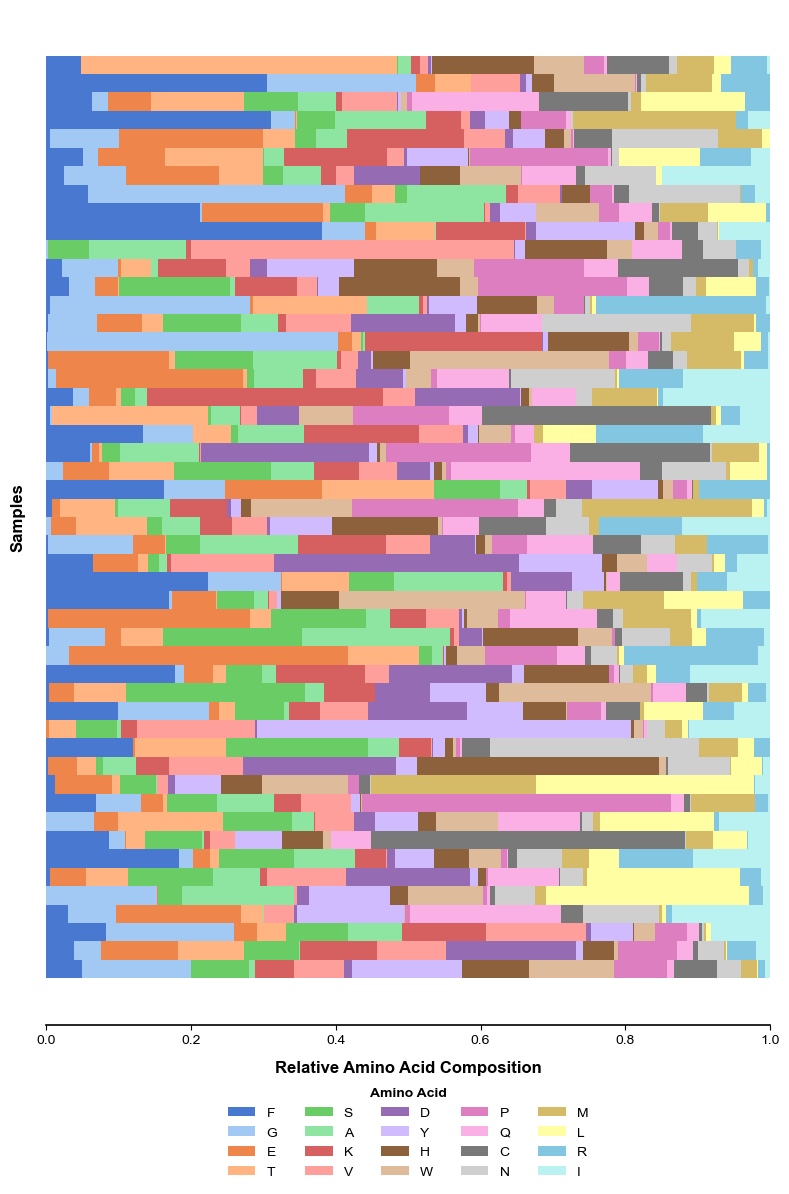

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 模拟真实数据 (20种氨基酸, 50个样本)
np.random.seed(42)
amino_acids = list('ACDEFGHIKLMNPQRSTVWY')
n_samples = 50
samples = [f'S{i+1}' for i in range(n_samples)]

# 模拟不均匀的分布
data = np.random.dirichlet(np.ones(20)*0.5, size=n_samples) 
df = pd.DataFrame(data, columns=amino_acids, index=samples)

# 2. 按总体平均丰度降序排列
mean_abundance = df.mean().sort_values(ascending=False)
ordered_aas = mean_abundance.index.tolist()

# 3. 生成 20 种不重复的莫兰迪配色
palette_muted = sns.color_palette("muted", 10)
palette_pastel = sns.color_palette("pastel", 10)
colors = [val for pair in zip(palette_muted, palette_pastel) for val in pair]
color_mapping = dict(zip(ordered_aas, colors))

# 4. 绘制图形 (改为水平条形图)
plt.rcParams['font.sans-serif'] = ['Arial']
# 调整画布比例，纵向拉长以容纳更多样本
fig, ax = plt.subplots(figsize=(8, 12)) 

# 无缝水平堆叠图
left_margin = np.zeros(n_samples)
for aa in ordered_aas:
    # 注意：bar改为barh，bottom改为left，width改为height
    ax.barh(df.index, df[aa], left=left_margin, color=color_mapping[aa], 
           height=1.0, edgecolor='none', label=aa)
    left_margin += df[aa]

# 5. SCI 级别细节美化
# 反转Y轴，让 S1 排在最上方，符合阅读习惯
ax.invert_yaxis()

# 极简坐标轴
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # 隐藏左侧边框线，保持清爽
ax.spines['bottom'].set_linewidth(1.2)

ax.set_xlabel("Relative Amino Acid Composition", fontweight='bold', fontsize=12, labelpad=10)
ax.set_ylabel("Samples", fontweight='bold', fontsize=12, labelpad=15)

ax.set_xlim(0, 1)
# 隐藏密集的样本刻度标签 (如果样本少于20个，可以删除这行以显示样本名)
ax.set_yticks([]) 

# 6. 图例排版优化
# 因为画布变长了，将20个图例放置在图表底部更为和谐
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Amino Acid', title_fontproperties={'weight':'bold'},
          loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5, frameon=False)

plt.tight_layout()
plt.savefig('AA_composition_horizontal.pdf', dpi=300, bbox_inches='tight')